# Case Study: Movie Ticket Sales Analysis

### Business Problem
A movie theater wants to analyze ticket sales and answer:
- Which movie generated the highest revenue?
- Which day had the highest ticket sales?
- How are ticket revenues distributed?
- Does selling more tickets increase revenue?
- What percentage of total revenue comes from each movie?

#### Dataset

In [1]:
data = {
    'Date': [
        '2025-06-01','2025-06-01',
        '2025-06-02','2025-06-02',
        '2025-06-03','2025-06-03',
        '2025-06-04','2025-06-04',
        '2025-06-05','2025-06-05'
    ],

    'Movie': [
        'Movie A','Movie B',
        'Movie A','Movie C',
        'Movie B','Movie C',
        'Movie A','Movie B',
        'Movie C','Movie A'
    ],

    'Tickets_Sold': [
        120, 90,
        150, 80,
        100, 110,
        180, 95,
        130, 200
    ],

    'Revenue': [
        24000, 18000,
        30000, 16000,
        20000, 22000,
        36000, 19000,
        26000, 40000
    ]
}

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.DataFrame(data)

In [4]:
df.head()

,Date,Movie,Tickets_Sold,Revenue
0,2025-06-01,Movie A,120,24000
1,2025-06-01,Movie B,90,18000
2,2025-06-02,Movie A,150,30000
3,2025-06-02,Movie C,80,16000
4,2025-06-03,Movie B,100,20000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          10 non-null     object
 1   Movie         10 non-null     object
 2   Tickets_Sold  10 non-null     int64 
 3   Revenue       10 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 452.0+ bytes


In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce') 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          10 non-null     datetime64[ns]
 1   Movie         10 non-null     object        
 2   Tickets_Sold  10 non-null     int64         
 3   Revenue       10 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 452.0+ bytes


# 

### Task 1: Revenue by Movie
- Which movie generated the highest revenue?

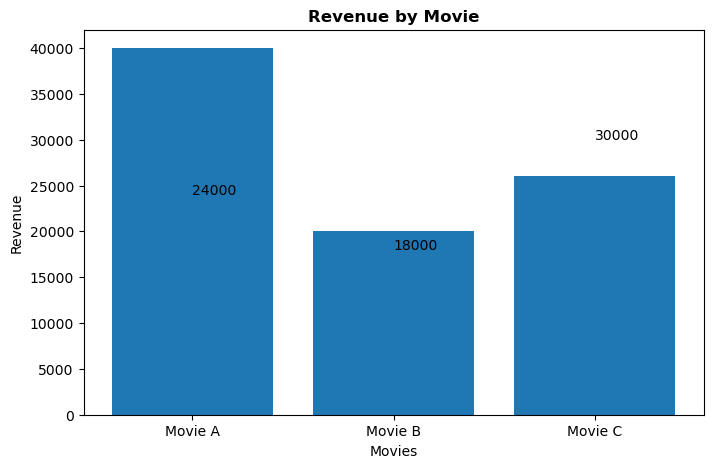

In [20]:
plt.figure(figsize=(8,5))
plt.bar(df['Movie'], df['Revenue'])
plt.title('Revenue by Movie', weight='bold')
plt.xlabel('Movies')
plt.ylabel('Revenue')
for i , v in enumerate(df['Revenue']):
    plt.annotate(v, xy=(i,v))
plt.show()

In [21]:
movie_revenue = (df.groupby('Movie')['Revenue'].sum().reset_index())

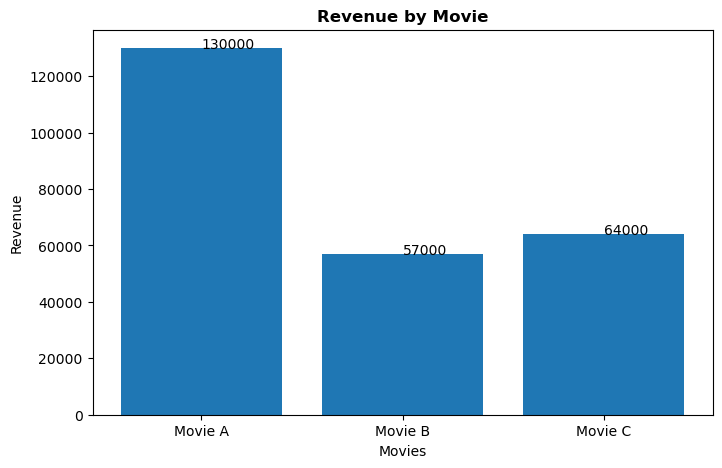

In [24]:
plt.figure(figsize=(8,5))
plt.bar(movie_revenue['Movie'], movie_revenue['Revenue'])
plt.title('Revenue by Movie', weight='bold')
plt.xlabel('Movies')
plt.ylabel('Revenue')
for i , v in enumerate(movie_revenue['Revenue']):
    plt.annotate(v, xy=(i,v))
plt.show()

# 

### Task 2: Daily Revenue Trend
- Which day earned the highest revenue?

In [25]:
# DData Preparation 
daily_revenue= df.groupby('Date')['Revenue'].sum().reset_index()

In [26]:
daily_revenue

,Date,Revenue
0,2025-06-01,42000
1,2025-06-02,46000
2,2025-06-03,42000
3,2025-06-04,55000
4,2025-06-05,66000


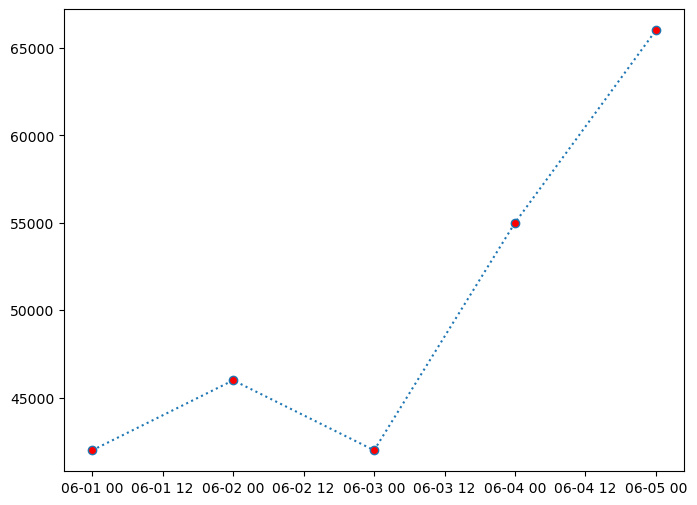

In [30]:
plt.figure(figsize=(8,6))
plt.plot(daily_revenue['Date'], daily_revenue['Revenue'], marker='o', markerfacecolor='r', linestyle=':')
plt.show()

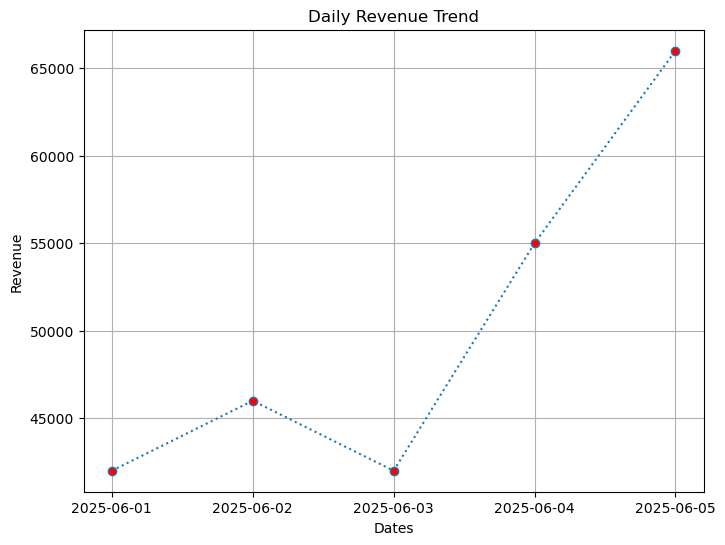

In [34]:
plt.figure(figsize=(8,6))
plt.plot(daily_revenue['Date'], daily_revenue['Revenue'], marker='o', markerfacecolor='r', linestyle=':')
plt.title('Daily Revenue Trend',weight=True)
plt.xlabel('Dates')
plt.ylabel('Revenue')
plt.xticks(daily_revenue['Date'])
plt.grid(True)
plt.show()

### Task 3: Revenue Distribution
- How are revenues distributed?

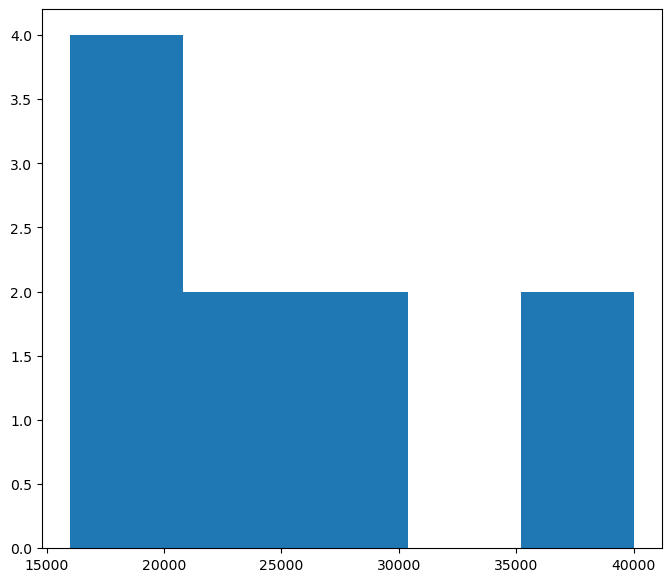

In [36]:
plt.figure(figsize=(8,7))
plt.hist(df['Revenue'], bins=5)
plt.show()

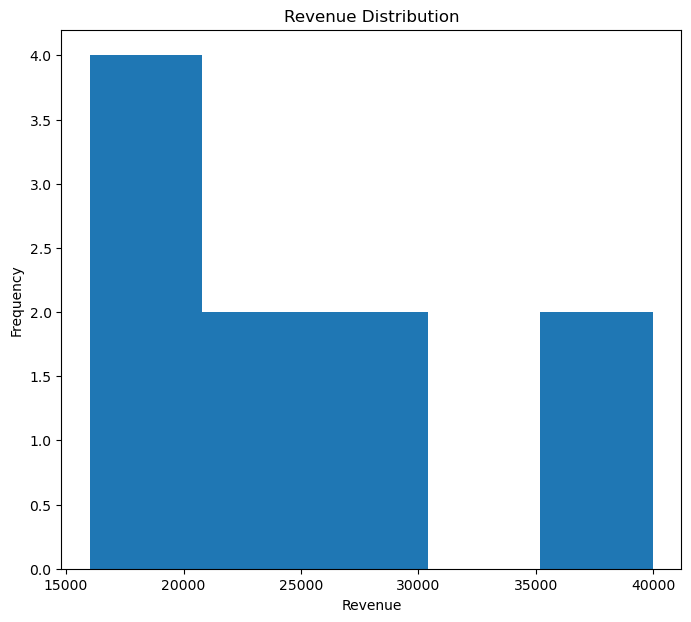

In [39]:
plt.figure(figsize=(8,7))
plt.hist(df['Revenue'],bins=5)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

# 

### Task 4: Tickets Sold vs Revenue
- Do more ticket sales lead to higher revenue?

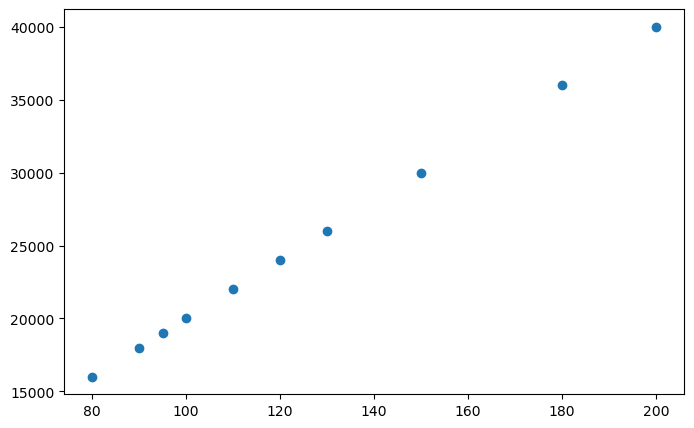

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(df['Tickets_Sold'], df['Revenue'])
plt.show()

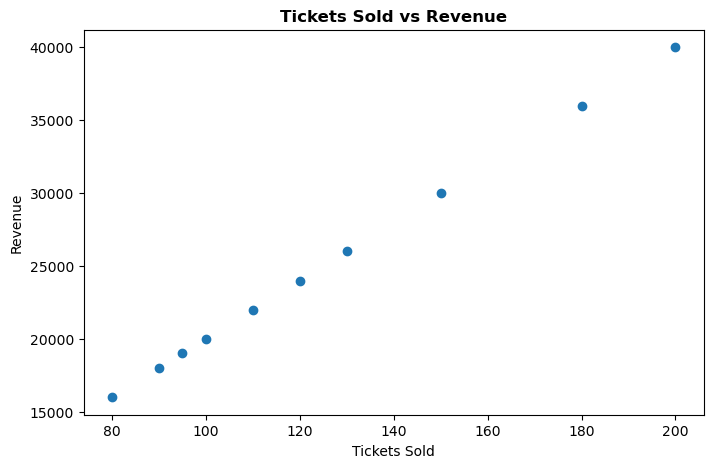

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df['Tickets_Sold'], df['Revenue'])
plt.title('Tickets Sold vs Revenue',weight='bold')
plt.xlabel('Tickets Sold')
plt.ylabel('Revenue')
plt.show()

# 

### Task 5: Revenue Share by Movie
- How much does each movie contribute to total revenue?

In [44]:
movie_revenue

,Movie,Revenue
0,Movie A,130000
1,Movie B,57000
2,Movie C,64000


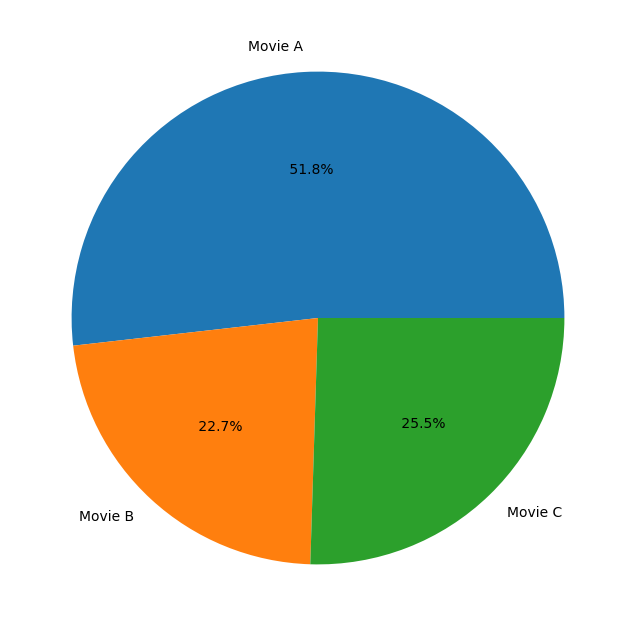

In [48]:
plt.figure(figsize=(10,8))
plt.pie(movie_revenue['Revenue'], labels=movie_revenue['Movie'],autopct='% 0.1f%%')
plt.show()

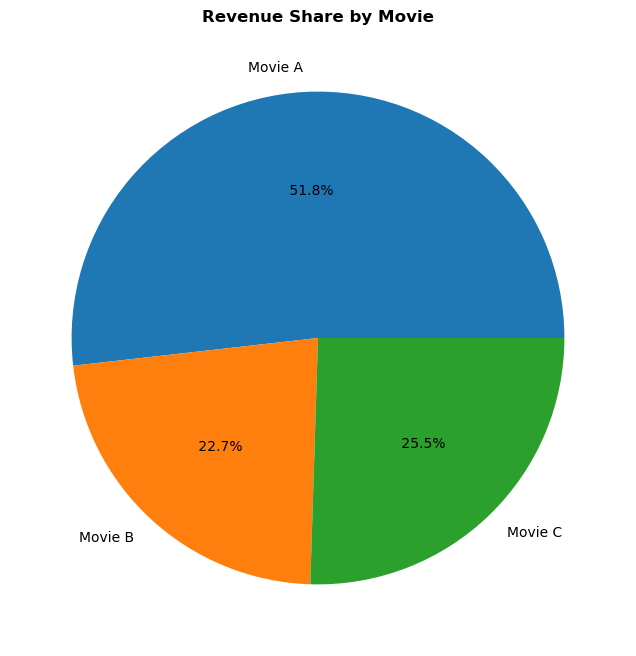

In [51]:
plt.figure(figsize=(10,8))
plt.pie(movie_revenue['Revenue'], labels=movie_revenue['Movie'],autopct='% 0.1f%%')
plt.title('Revenue Share by Movie',weight='bold')
plt.show()